In [98]:
import numpy as np
from numpy.fft import fftfreq, fft, ifft
import matplotlib.pyplot as plt

data = np.loadtxt('Daten_Frage_A.dat', delimiter='|')
t = data[:, 0]
U = data[:, 1]

print(np.std(U))

0.025333204570220483


1-tes Moment: 25.056
2-tes zentrales Moment: 9.111
1-tes zentrales Moment: 4.633


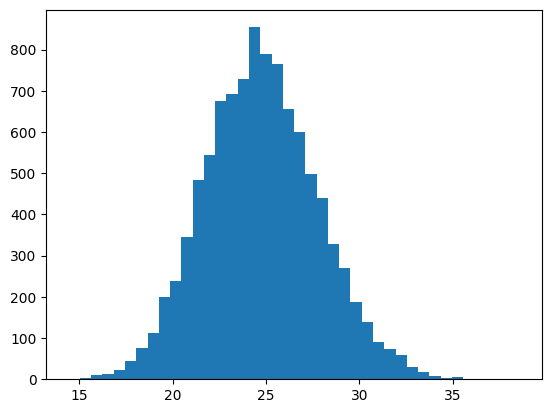

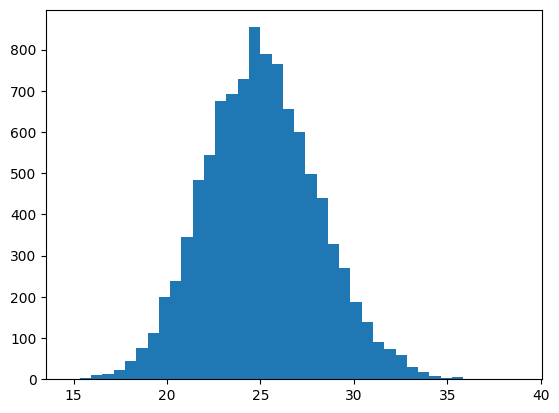

In [ ]:
data = np.loadtxt('Daten_Frage_B2.txt', delimiter=',')
t = data[:, 0]
x = data[:, 1]

def moment(data, n):
    return np.sum(data**n)/len(data)

def central_moment(data, n):
    return np.mean((data - np.mean(data))**n)

print(f'1-tes Moment: {moment(x, 1):0.3f}')
print(f'2-tes zentrales Moment: {central_moment(x, 2):0.3f}')
print(f'3-tes zentrales Moment: {central_moment(x, 3):0.3f}')

counts, bin_edges = np.histogram(x, bins=40)

fig, ax = plt.subplots()
ax.bar(bin_edges[:-1], counts, width=np.diff(bin_edges))


fig = plt.figure()
ax = fig.add_subplot(1, 1, 1)
ax.hist(x, bins=40);

0.003321348866250454
0.0011291280412572627
2.941516590582761
2.833965118229788e-09


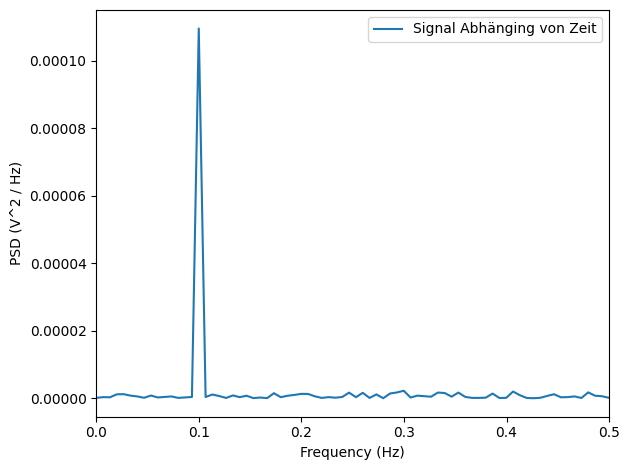

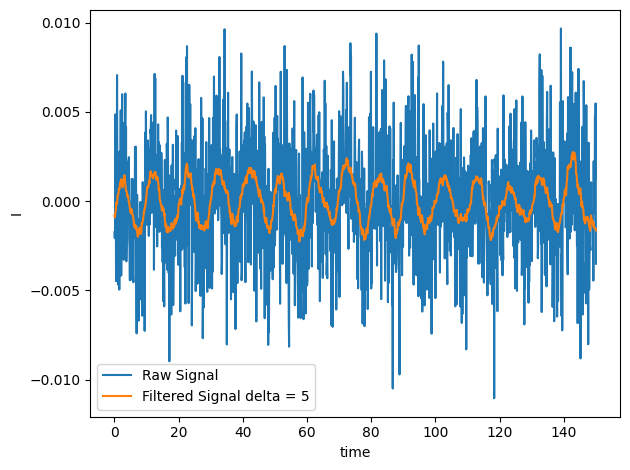

In [ ]:
data = np.loadtxt('Daten_Frage_C1.txt', delimiter='\t')
t = data[:, 0]
U = data[:, 1]

# plt.plot(time_s, signal_V)

def plot_plot(*data_pairs, xlabel='x', ylabel='y', scale='linear', title='', xlim=None, ylim=None):
    fig = plt.figure()
    ax = fig.add_subplot(1, 1, 1)
    for pair in data_pairs:
        if len(pair) == 1:
            y, label = pair[0], ''
            x = np.arange(len(y))
        elif len(pair) == 2:
            y, label = pair[0], pair[1]
            x = np.arange(len(y))
        else:
            x, y, label = pair[0], pair[1], pair[2]
        yerr = pair[3] if len(pair) > 3 else None
        fmt = pair[4] if len(pair) > 4 else '-'
        ax.errorbar(x, y, yerr=yerr, fmt=fmt, capsize=5, label=label)
    
    if scale == 'logx':
        ax.set_xscale('log')
    elif scale == 'logy':
        ax.set_yscale('log')
    elif scale == 'loglog':
        ax.set_xscale('log')
        ax.set_yscale('log')
    
    if xlim: ax.set_xlim(xlim)
    if ylim: ax.set_ylim(ylim)

    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend()
    fig.tight_layout()

def compute_psd(signal, t, return_spectrum=False):
    dt = t[1] - t[0]
    N = len(t)
    frequency = fftfreq(N, d=dt)
    spectrum = fft(signal)
    psd = dt / N * np.abs(spectrum) ** 2
    mask = frequency >= 0
    if return_spectrum:
        return frequency[mask], psd[mask], spectrum
    return frequency[mask], psd[mask]

freq, psd = compute_psd(U, t)

# print(freq[np.argmax(psd)])

def moving_average(x, delta, edges='repeat'):
    N = len(x)

    filtered_array = np.zeros(N)

    if edges == 'repeat':
        padded_array = np.concatenate([np.ones(delta) * x[0], x, np.ones(delta) * x[-1]])
    elif edges == 'cut':
        padded_array = np.concatenate([np.zeros(delta), x, np.zeros(delta)])
    elif edges == 'wrap':
        padded_array = np.concatenate([x[-delta:], x, x[:delta]])
    else:
        raise ValueError("Invalid edge handling method. Choose 'repeat', 'cut', or 'wrap'.")
    
    for i in range(N):
        filtered_array[i] = np.mean(padded_array[i:i + 2 * delta])

    if edges == 'cut':
        return filtered_array[delta:-delta]
    
    return filtered_array

plot_plot(
    (freq, psd, 'Signal Abhänging von Zeit'),
    xlabel='Frequency (Hz)',
    ylabel='PSD (V^2 / Hz)',
    xlim=(0, 0.5)
)

U_new = moving_average(U, 15) # mitteln über das 2 fache von dem. also über 30 punkte.

# faktor alpha von sigma wird np.sqrt(30) sein.

plot_plot(
    (t, U, 'Raw Signal'),
    (t, U_new, 'Filtered Signal delta = 5'),
    xlabel='time',
    ylabel='I'
)

print(np.std(U))
print(np.std(U_new))
print(np.std(U) / np.std(U_new))

sigma_U = np.std(U)
sigma_ADC_sq = 3e-6
g = 1e6

sigma_z = np.sqrt(sigma_U**2 - sigma_ADC_sq) / g
print(sigma_z)

In [101]:
data = np.loadtxt('Daten_Frage_D2.txt', delimiter='\t')
t = data[:, 0]

T = data[:, 1]
m = data[:, 2]
k = []
for i in range(0, len(t)):
    k.append(m[i] * ((2 * np.pi) / T[i]) ** 2)


print(np.mean(T))
print(np.std(T)**2)
print(np.mean(m))
print(np.std(m)**2)
print(np.mean(k))
print(np.std(k)**2)

1.6001863590039571
0.007230846480334927
0.8057916862954384
0.01472770450571337
12.422336086714076
2.7057991993768162


14.544353229175812
-11.761031832605347
3.9892074237586597
-0.3398484346885166


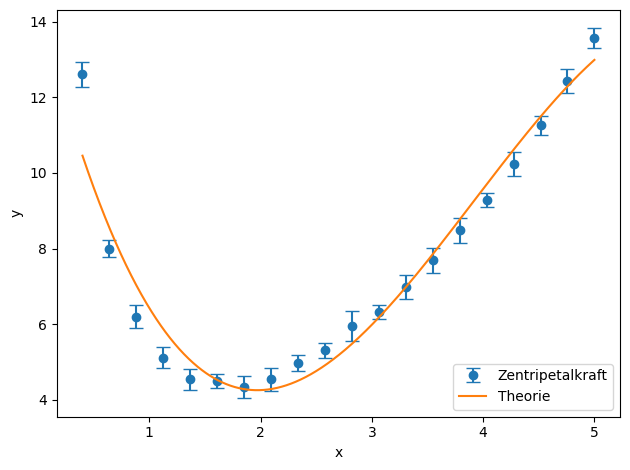

In [102]:
data = np.loadtxt('Daten_Frage_H1.txt',skiprows=1, delimiter=',')

x = data[:, 0]
y = data[:, 1]
sigma_y = data[:, 2]

a3, a2, a1, a0 = np.polyfit(x, y, 3, w=1/sigma_y)

print(a0)
print(a1)
print(a2)
print(a3)

x_space = np.linspace(x[0], x[-1], 1000)

plot_plot(
    (x, y, 'Zentripetalkraft', sigma_y, 'o'),
    (x_space, a0 + a1 * x_space + a2 * x_space**2 + a3 * x_space**3, 'Theorie'),
)

In [103]:
# Task 1: Read the data from data.csv

# Hint: This one we already solved for you ;)
import pandas as pd
import numpy as np
import pandas as pd
from sklearn import linear_model
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import Ridge
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

df = pd.read_csv("data.csv")

X = df.drop(['target'], axis=1)
y = df['target']

display(df.head())
# Task 2: Split data into training and testing.

from sklearn.model_selection import train_test_split

# Hint: this function takes as parameter X, y, and a 'test_size' ;)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=41)

# Task 3: Train a model on your data.
scaler = StandardScaler()
scaler.fit(X_train) # fit scaler on training data 

X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Hint 1: Below are some options for models ;)
# Hint 2: To train a model, use the method 'fit' with some X and some y.

lr = LogisticRegression()
lr.fit(X_train_scaled, y_train)

# Vorhersagegenauigkeit berechnen. 
accuracy_train = accuracy_score(y_train, lr.predict(X_train_scaled))
accuracy_test = accuracy_score(y_test, lr.predict(X_test_scaled))

print("Accuracy Trainingsdaten: ", accuracy_train)
print("Accuracy Testdaten: ", accuracy_test)

# Task 4: Measure the quality of your estimator in the test data.



# Hint: Here you use your estimator to 'predict' the labels for your
# test data.
y_pred = lr.predict(X_test_scaled)

# Hint: Call accuracy_score with the following arguments:
# 1. the true labels.
# 2. the labels you predicted.

# Task 5: Use your estimator to make predictions for the examples in X_final.csv

X_final = pd.read_csv("X_final.csv")
X_final_scaled = scaler.transform(X_final)
y_final = lr.predict(X_final_scaled)
print(y_final)


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,4.6,3.6,1.0,0.2,0
1,5.7,4.4,1.5,0.4,0
2,6.7,3.1,4.4,1.4,1
3,4.8,3.4,1.6,0.2,0
4,4.4,3.2,1.3,0.2,0


Accuracy Trainingsdaten:  0.9880952380952381
Accuracy Testdaten:  0.8888888888888888
[2 1 2 1 1 1 0 2 0 1]


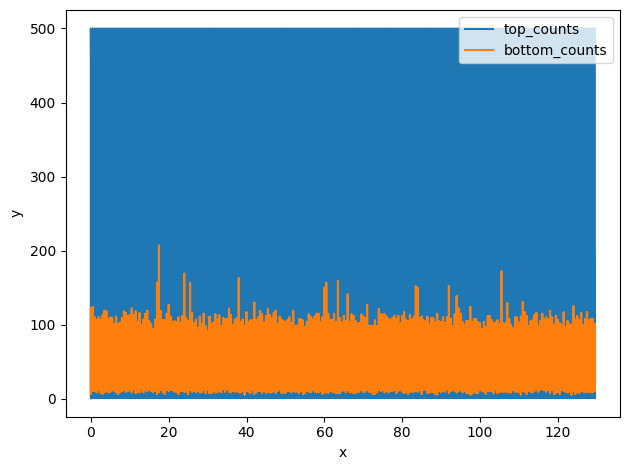

In [104]:
data = np.loadtxt('photodetector_counts.csv', skiprows=1, delimiter=',')
timestamp = data[:, 0]
top_counts = data[:, 1]
bottom_counts = data[:, 2]

plot_plot(
    (timestamp, top_counts, 'top_counts'),
    (timestamp, bottom_counts, 'bottom_counts'),
)